# Latihan 7 : Logit Biner
### 1. Import Library

In [38]:
import pandas as pd 
#import numpy as np 
from sklearn.datasets import make_classification 
from imblearn.over_sampling import RandomOverSampler 
#from imblearn.under_sampling import RandomUnderSampler 
from collections import Counter 
from sklearn.model_selection import train_test_split 
#from sklearn.linear_model import LogisticRegression 
#from sklearn import metrics 
#import seaborn as sn 
import matplotlib.pyplot as plt

### 2. Membuka Dataset

In [39]:
dataset = pd.read_csv("C:\\Users\\faizr\\Documents\\Data-Data Faiz\\File Kuliah dkk\\Semester 2\\Pemodelan Statistik Terapan\\klasifikasi__UKT_komplit.csv") 
dataset.head(10)

,No.,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
0,1,1,4000000,1,1,0,2,0
1,2,1,2500000,0,1,0,3,0
2,3,1,6000000,1,2,0,2,0
3,4,1,5440500,1,2,0,2,0
4,5,1,10000000,0,1,1,3,0
5,6,1,1000000,0,1,0,3,1
6,7,1,20000000,1,2,1,3,0
7,8,1,15000000,1,1,0,3,0
8,9,4,4000000,1,1,1,3,0
9,10,1,0,1,2,0,1,0


### 3. Statistik Deskriptif

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   No.           1707 non-null   int64
 1   StatusOrtu    1707 non-null   int64
 2   Penghasilan   1707 non-null   int64
 3   Status_Rumah  1707 non-null   int64
 4   JMotor        1707 non-null   int64
 5   Jmobil        1707 non-null   int64
 6   DayaLis       1707 non-null   int64
 7   KIPK          1707 non-null   int64
dtypes: int64(8)
memory usage: 106.8 KB


In [8]:
dataset.describe()

,No.,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
count,1707.000000,1707.000000,1.707000e+03,1707.000000,1707.000000,1707.000000,1707.000000,1707.000000
mean,854.000000,1.164030,5.195012e+06,0.807264,1.968366,0.357938,2.205038,0.157586
std,492.912771,0.565764,5.552922e+06,0.394563,0.823274,0.541534,0.676276,0.364460
min,1.000000,1.000000,-1.000000e+06,0.000000,0.000000,0.000000,1.000000,0.000000
25%,427.500000,1.000000,2.000000e+06,1.000000,1.000000,0.000000,2.000000,0.000000
50%,854.000000,1.000000,4.000000e+06,1.000000,2.000000,0.000000,2.000000,0.000000
75%,1280.500000,1.000000,6.131916e+06,1.000000,2.000000,1.000000,3.000000,0.000000
max,1707.000000,4.000000,7.300000e+07,1.000000,5.000000,3.000000,3.000000,1.000000


In [42]:
del(dataset["No."]) 
dataset.describe()

,StatusOrtu,Penghasilan,Status_Rumah,JMotor,Jmobil,DayaLis,KIPK
count,1707.000000,1.707000e+03,1707.000000,1707.000000,1707.000000,1707.000000,1707.000000
mean,1.164030,5.195012e+06,0.807264,1.968366,0.357938,2.205038,0.157586
std,0.565764,5.552922e+06,0.394563,0.823274,0.541534,0.676276,0.364460
min,1.000000,-1.000000e+06,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,2.000000e+06,1.000000,1.000000,0.000000,2.000000,0.000000
50%,1.000000,4.000000e+06,1.000000,2.000000,0.000000,2.000000,0.000000
75%,1.000000,6.131916e+06,1.000000,2.000000,1.000000,3.000000,0.000000
max,4.000000,7.300000e+07,1.000000,5.000000,3.000000,3.000000,1.000000


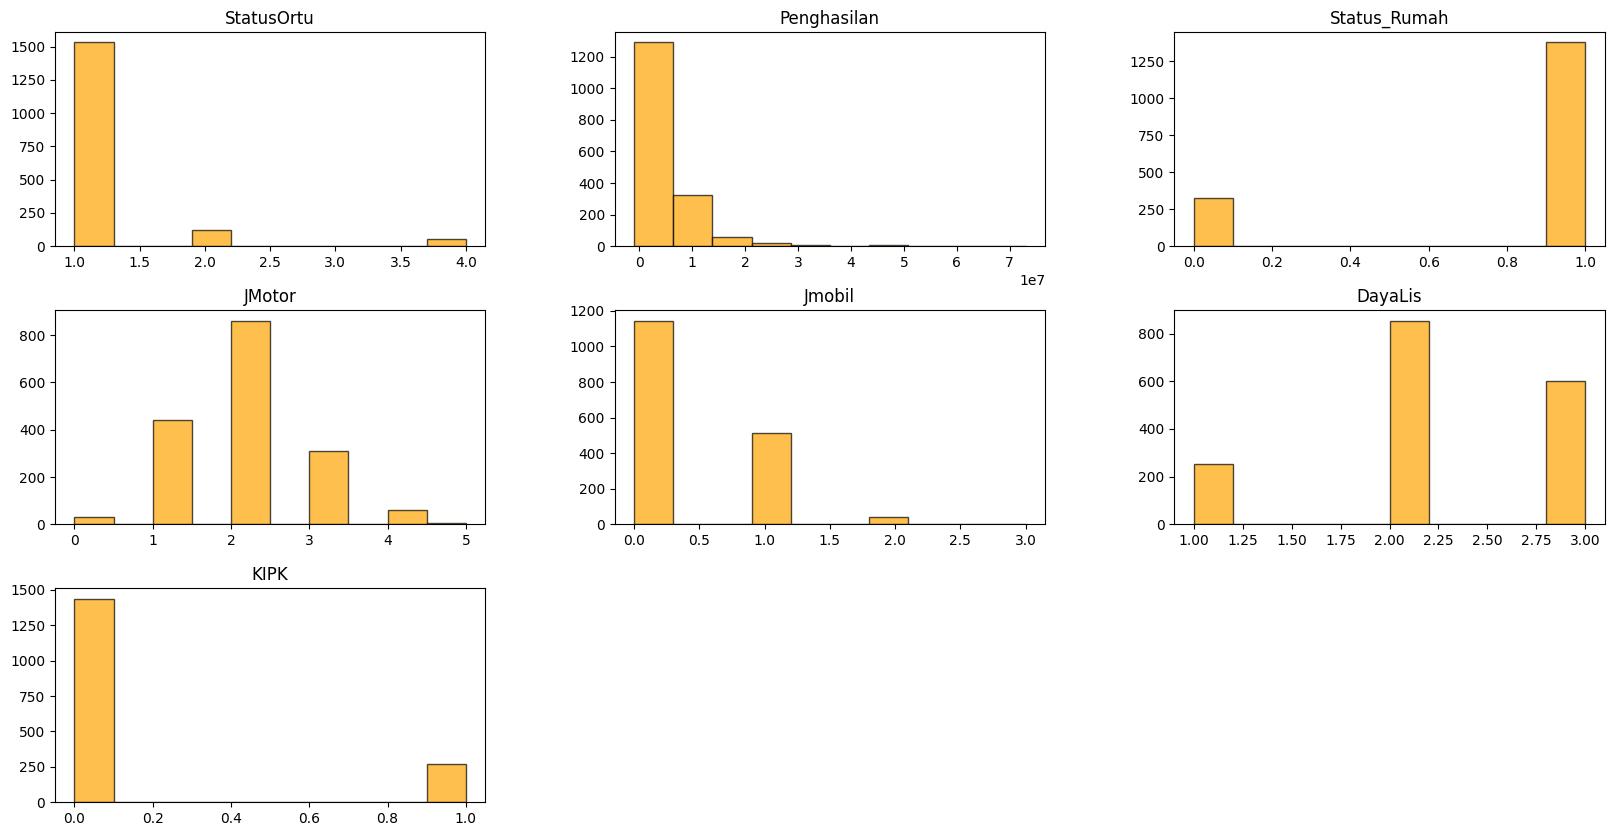

In [43]:
user_data_for_hist = dataset 
user_data_for_hist.hist(figsize=(20,10),alpha = 0.7, color = 'orange',edgecolor ='black',grid=False);

### 4. Normalisasi data dan oversampling

In [20]:
from sklearn.preprocessing import MinMaxScaler 
array = dataset.values 
X = array[:,1:6] #slicing dataframe ke dalam array 
y = array[:,6] 
scaler = MinMaxScaler() # transform data 
X = scaler.fit_transform(X) 
print(X)

[[0.06756757 1.         0.2        0.         0.5       ]
 [0.0472973  0.         0.2        0.         1.        ]
 [0.09459459 1.         0.4        0.         0.5       ]
 ...
 [0.02567568 1.         0.6        0.33333333 0.5       ]
 [0.08108108 0.         0.4        0.         0.        ]
 [0.12162162 1.         0.6        0.         0.5       ]]


In [21]:
y = y.astype('int')
print(y)

[0 0 0 ... 0 0 0]


In [22]:
print(Counter(y))

Counter({np.int64(0): 1438, np.int64(1): 269})


In [15]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [19]:
# instantiating the random over sampler 
ros = RandomOverSampler() 
# resampling x_train, y_train 
X_ros, y_ros = ros.fit_resample(x_train, y_train) 
# new class distribution 
print(Counter(y_ros))

Counter({np.int64(0): 1156, np.int64(1): 1156})


### 5. Import Library 2

In [ ]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 
# from sklearn.ensemble import RandomForestClassifier 
#from sklearn.svm import SVM 
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix,accuracy_score 
logmodel = LogisticRegression()

### 6.a Model-1 dengan data asli

In [29]:
model1=logmodel.fit(x_train, y_train) 
predictions1a = model1.predict(x_train) 
predictions1b = model1.predict(x_test) 
predictions1c = model1.predict_proba(x_test)[:,1] 
print("-------Model-1: Logit Biner dengan Dataset Asli (Train)-------") 
print("Kinerja Data Training:") 
print(classification_report(y_train, predictions1a))
print("Mariks Konfusi dari Model-1 Train:")  
print(confusion_matrix(y_train, predictions1a))
print("Nilai Akurasi Model-1 Train:") 
print(accuracy_score(y_train, predictions1a)) 

-------Model-1: Logit Biner dengan Dataset Asli (Train)-------
Kinerja Data Training:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92      1156
           1       0.48      0.06      0.11       209

    accuracy                           0.85      1365
   macro avg       0.67      0.53      0.51      1365
weighted avg       0.80      0.85      0.79      1365

Mariks Konfusi dari Model-1 Train:
[[1142   14]
 [ 196   13]]
Nilai Akurasi Model-1 Train:
0.8461538461538461


In [31]:
print("-------Model-1: Logit Biner dengan Dataset Asli (Test)-------") 
print("Kinerja Data Testing:") 
print(classification_report(y_test, predictions1b))
print("Mariks Konfusi dari Model-1 Test:") 
print(confusion_matrix(y_test, predictions1b))
print("Nilai Akurasi Model-1 Test:") 
print(accuracy_score(y_test, predictions1b))

-------Model-1: Logit Biner dengan Dataset Asli (Test)-------
Kinerja Data Testing:
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       282
           1       0.33      0.05      0.09        60

    accuracy                           0.82       342
   macro avg       0.58      0.51      0.49       342
weighted avg       0.74      0.82      0.76       342

Mariks Konfusi dari Model-1 Test:
[[276   6]
 [ 57   3]]
Nilai Akurasi Model-1 Test:
0.8157894736842105


### 6.b Model-2 dengan data oversampling

In [45]:
model2=logmodel.fit(X_ros, y_ros) 
predictions2a = model2.predict(X_ros) 
predictions2b = model2.predict(x_test) 
predictions2c = model2.predict_proba(x_test)[:,1] 
print("-------Model-2: Logit Biner dengan Dataset Over-sampling (Train)-------") 
print("Kinerja Data Training:") 
print(classification_report(y_ros, predictions2a))
print("Mariks Konfusi dari Model-2 Train:") 
print(confusion_matrix(y_ros, predictions2a))
print("Nilai Akurasi Model-2 Train:") 
print(accuracy_score(y_ros, predictions2a)) 

-------Model-2: Logit Biner dengan Dataset Over-sampling (Train)-------
Kinerja Data Training:
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1156
           1       0.73      0.85      0.78      1156

    accuracy                           0.76      2312
   macro avg       0.77      0.76      0.76      2312
weighted avg       0.77      0.76      0.76      2312

Mariks Konfusi dari Model-2 Train:
[[786 370]
 [176 980]]
Nilai Akurasi Model-2 Train:
0.763840830449827


In [48]:
print("-------Model-2: Logit Biner dengan Dataset Over-sampling (Test)-------") 
print("Kinerja Data Testing:") 
print(classification_report(y_test, predictions2b))
print("Mariks Konfusi dari Model-2 Test:") 
print(confusion_matrix(y_test, predictions2b))
print("Nilai Akurasi Model-2 Test:") 
print(accuracy_score(y_test, predictions2b))

-------Model-2: Logit Biner dengan Dataset Over-sampling (Test)-------
Kinerja Data Testing:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83       282
           1       0.41      0.87      0.55        60

    accuracy                           0.75       342
   macro avg       0.68      0.80      0.69       342
weighted avg       0.87      0.75      0.78       342

Mariks Konfusi dari Model-2 Test:
[[206  76]
 [  8  52]]
Nilai Akurasi Model-2 Test:
0.7543859649122807


### 7. Perbandingan antar model 

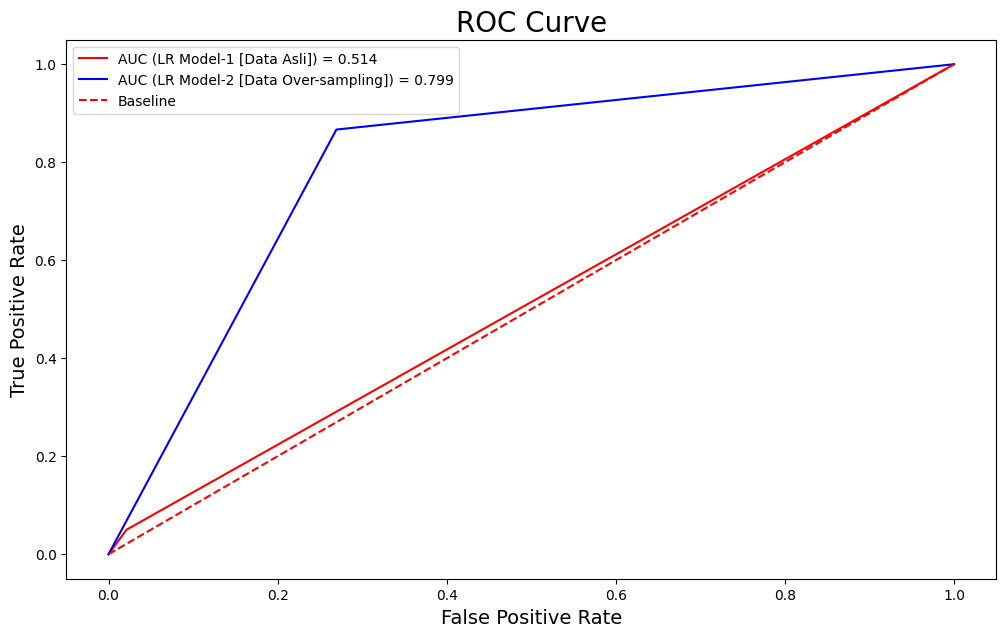

In [36]:
from sklearn.metrics import roc_auc_score, roc_curve 
#y_test_int = y_test.replace({'Good': 1, 'Bad': 0}) 
auc1 = roc_auc_score(y_test, predictions1b)
fpr1, tpr1, thresholds1 = roc_curve(y_test, predictions1b) 
auc2 = roc_auc_score(y_test, predictions2b) 
fpr2, tpr2, thresholds2 = roc_curve(y_test, predictions2b) 
plt.figure(figsize=(12, 7)) 
plt.plot(fpr1, tpr1, label=f'AUC (LR Model-1 [Data Asli]) = {auc1:.3f}',color='red') 
plt.plot(fpr2, tpr2, label=f'AUC (LR Model-2 [Data Over-sampling]) = {auc2:.3f}',color='blue') 
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Baseline') 
plt.title('ROC Curve', size=20) 
plt.xlabel('False Positive Rate', size=14) 
plt.ylabel('True Positive Rate', size=14) 
plt.legend();